In [1]:
!pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


sns.set(style="whitegrid")


In [3]:
s3 = boto3.client("s3")

bucket_name = "housewhiz-analytics-data"

files = [
    "housing.csv",
    "hpi_master.csv",
    "Race.xlsx",
    "Resident Population by Age and Sex.xlsx",
    "Total Population by County.xlsx"
]

for file_name in files:
    s3.download_file(bucket_name, file_name, file_name)
    print(f"Downloaded {file_name}")

Downloaded housing.csv
Downloaded hpi_master.csv
Downloaded Race.xlsx
Downloaded Resident Population by Age and Sex.xlsx
Downloaded Total Population by County.xlsx


In [4]:
housing = pd.read_csv("housing.csv")
hpi = pd.read_csv("hpi_master.csv")

race = pd.read_excel("Race.xlsx")
age_sex = pd.read_excel("Resident Population by Age and Sex.xlsx")
population = pd.read_excel("Total Population by County.xlsx")

In [5]:
def explore(df, name):
    print("==============")
    print("Dataset:", name)
    print("==============")
    
    print("\nShape:")
    print(df.shape)
    
    print("\nColumns:")
    print(df.columns)
    
    print("\nData Types:")
    print(df.dtypes)
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())
    
    print("\nSummary Statistics:")
    print(df.describe(include='all'))

In [6]:
explore(housing, "Housing Data")
explore(hpi, "HPI Data")
explore(race, "Race Data")
explore(age_sex, "Age & Sex Data")
explore(population, "Population Data")

Dataset: Housing Data

Shape:
(20640, 10)

Columns:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Duplicate Rows:
0

Summary Statistics:
           longitude      latitude  housing_median_age   total_rooms  \
count   2

In [7]:
print("\n=== KEY INSIGHTS ===")

print("""
1. Housing Dataset:
- Contains 20,640 rows and 10 columns
- Missing values found in 'total_bedrooms' (207 missing)
- Strong candidate for predictive modeling due to numeric features
- 'median_income' likely a strong predictor of house value

2. HPI Dataset:
- Very large dataset (133k+ rows)
- Contains time-series data (year + period)
- Missing values in 'index_sa'
- Useful for analyzing housing trends over time

3. Census Datasets:
- Contain significant formatting issues
- Many missing values and duplicate rows
- Column names are inconsistent ( 'Unnamed: 1')
- Require cleaning before integration

4. Data Integration Challenges:
- Different granularities (property vs county vs metro)
- Need to align geographic identifiers
- Time-based alignment required for HPI data
""")


=== KEY INSIGHTS ===

1. Housing Dataset:
- Contains 20,640 rows and 10 columns
- Missing values found in 'total_bedrooms' (207 missing)
- Strong candidate for predictive modeling due to numeric features
- 'median_income' likely a strong predictor of house value

2. HPI Dataset:
- Very large dataset (133k+ rows)
- Contains time-series data (year + period)
- Missing values in 'index_sa'
- Useful for analyzing housing trends over time

3. Census Datasets:
- Contain significant formatting issues
- Many missing values and duplicate rows
- Column names are inconsistent ( 'Unnamed: 1')
- Require cleaning before integration

4. Data Integration Challenges:
- Different granularities (property vs county vs metro)
- Need to align geographic identifiers
- Time-based alignment required for HPI data



In [8]:
num_cols = housing.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = housing[col].quantile(0.25)
    Q3 = housing[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = housing[(housing[col] < lower) | (housing[col] > upper)].shape[0]
    
    print(col, "Outliers:", outliers)

longitude Outliers: 0
latitude Outliers: 0
housing_median_age Outliers: 0
total_rooms Outliers: 1287
total_bedrooms Outliers: 1271
population Outliers: 1196
households Outliers: 1220
median_income Outliers: 681
median_house_value Outliers: 1071


### Observations from Outlier Analysis

- Several variables (total_rooms, population, households) contain a large number of outliers.
- This is expected in real world housing data where distributions are often skewed.
- Median house value also contains outliers, which may represent high value properties or capped values.
- These outliers may impact model performance and may require transformation or normalization in later stages.

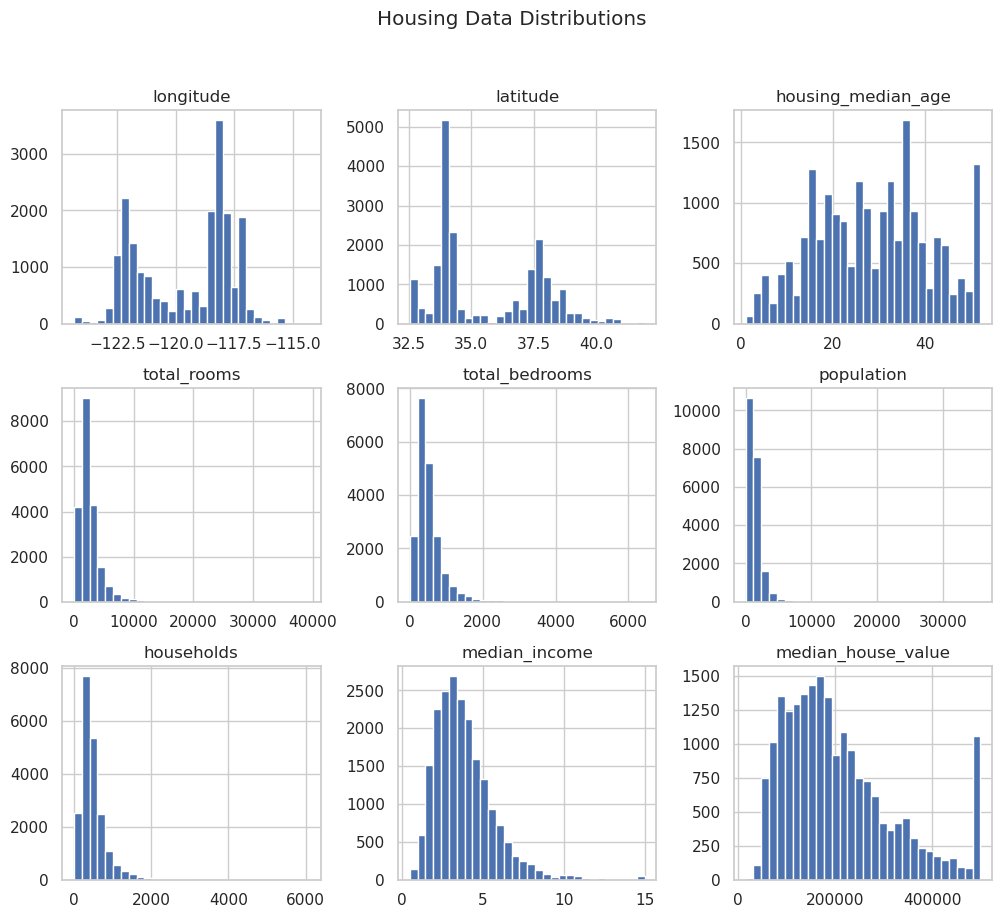

In [9]:
#Housing Histogram 
housing.hist(figsize=(12,10) , bins=30)
plt.suptitle("Housing Data Distributions")
plt.show()

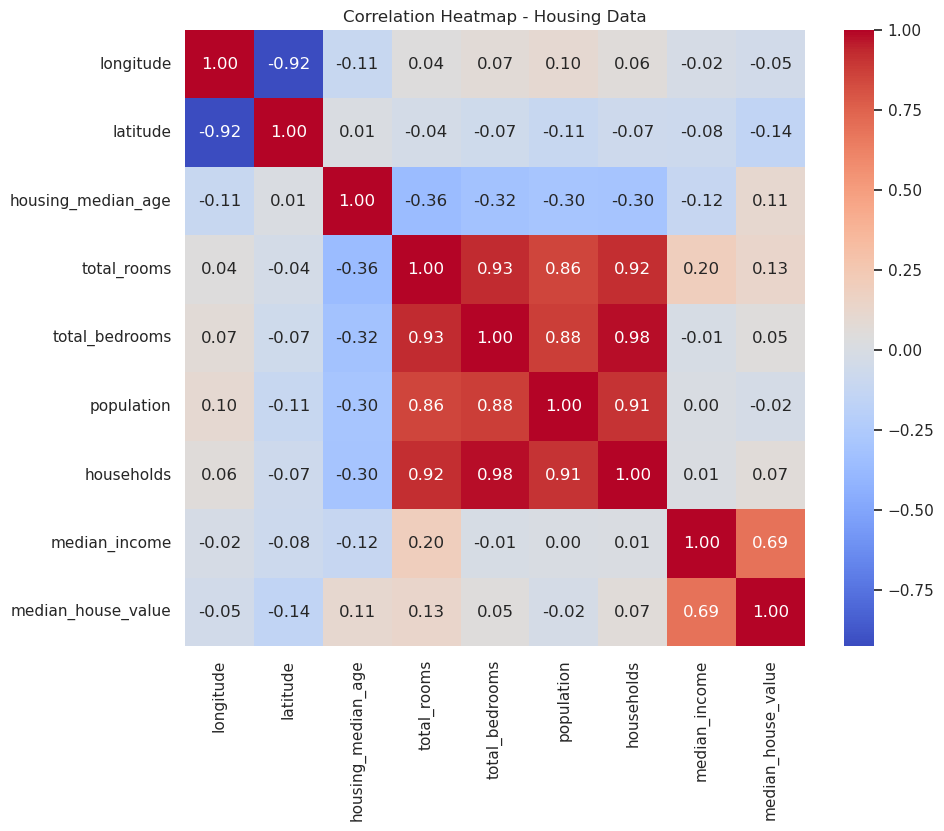

In [10]:
#Correlation Heat Map 
plt.figure(figsize=(10,8))
corr_housing = housing.corr(numeric_only = True)

sns.heatmap(corr_housing,annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap - Housing Data")
plt.show()

### Correlation Insights

- Median income shows a strong positive correlation with median house value.
- Features such as total_rooms and households show strong correlation with population related variables.
- Longitude and latitude show a strong negative linear correlations but are important for geographic patterns.

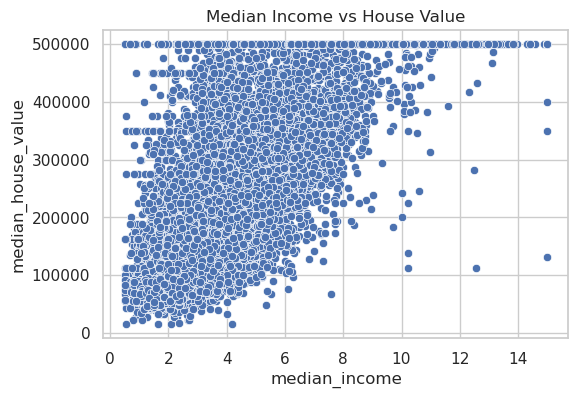

In [11]:
#Scatterplot of Median Income Vs Median House Value
plt.figure(figsize=(6,4))
sns.scatterplot(data=housing, x="median_income", y="median_house_value")
plt.title("Median Income vs House Value")
plt.show()

### Scatter Plot Observations (Median Income vs House Value)
- Strong positive relationship between median_income and median_house_value
- Higher income areas tend to have higher housing prices
- Data shows clear upward trend overall
- Noticeable clustering of values at the upper limit (~500,000)
- Indicates the target variable is capped
- Reduced variability at lower income levels
- Greater spread in house values at higher income levels
- median_income appears to be a strong predictor of housing price
- Some outliers exist at higher income levels with varying house values
- Relationship is not perfectly linear, suggesting influence from other features (location)

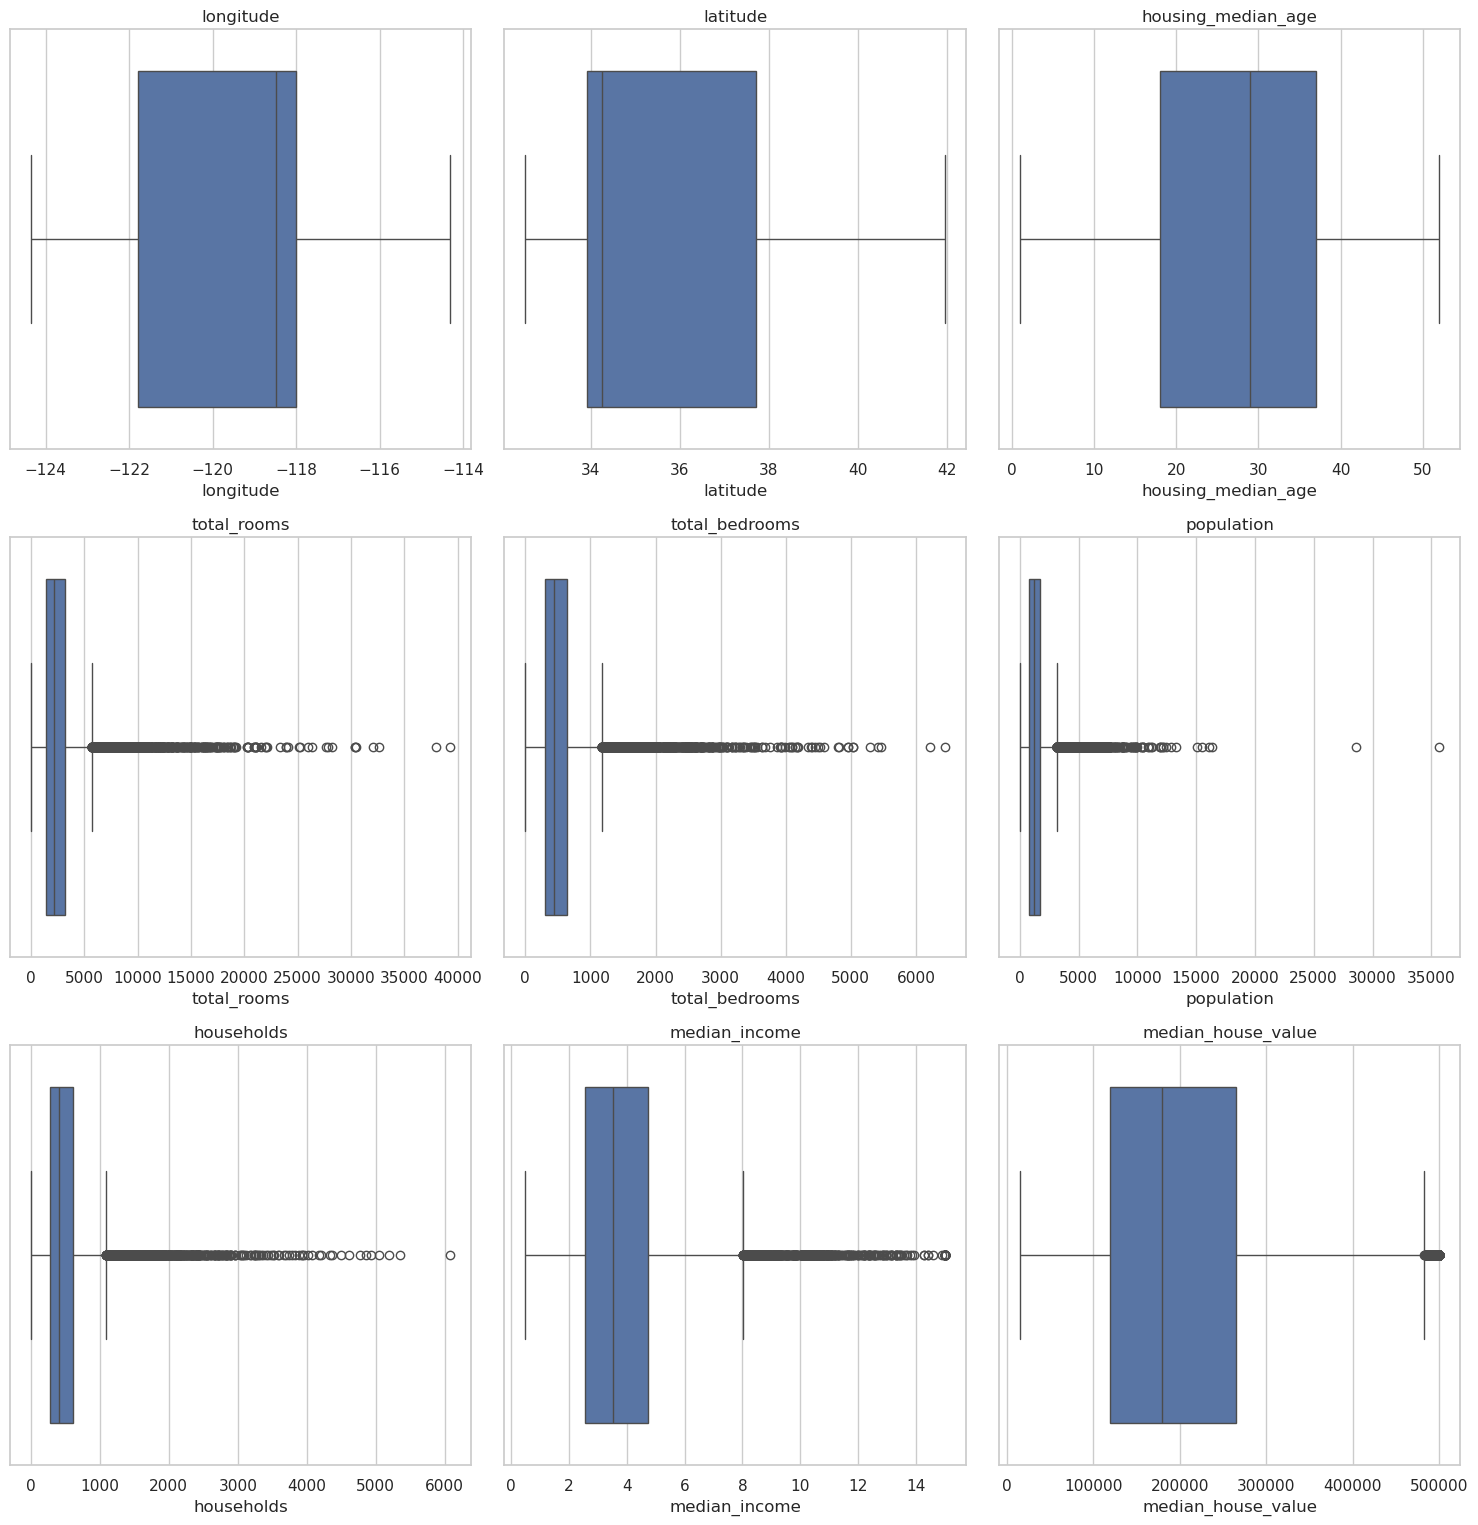

In [12]:
#Boxplot to Visualize Outlier
num_cols = housing.select_dtypes(include='number').columns

# Set grid size
cols = 3  # number of plots per row
rows = (len(num_cols) // cols) + 1

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=housing[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Data Preparation 

In [18]:
#Missing values in housing.csv file 
housing["total_bedrooms"] = housing["total_bedrooms"].fillna(housing["total_bedrooms"].median())

#confirmation 
housing["total_bedrooms"].isnull().sum()


0

### Feature Selection


In [19]:
x=housing.drop("median_house_value", axis =1)
y=housing["median_house_value"]


### Handling Categorical Values 

In [20]:
x=pd.get_dummies(x, columns=["ocean_proximity"], drop_first=True)

### Feature Engineering 


In [23]:
x["rooms_per_household"] = x["total_rooms"] / x["households"]
x["bedrooms_per_room"] = x["total_bedrooms"] / x["total_rooms"]
x["population_per_household"] = x["population"] / x["households"]

#log values for random forest 
x["total_rooms_log"] = np.log1p(x["total_rooms"])
x["population_log"] = np.log1p(x["population"])

### Scaling 


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

### Train/Test Split

In [30]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)



X_train shape: (16512, 17)
X_test shape: (4128, 17)


In [45]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_evaluate_and_compare(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    predictions = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    # Print metrics
    print(f"--- {model_name} ---")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}\n")
    
    # Actual vs Predicted plot
    plt.figure(figsize=(6,4))
    plt.scatter(y_test, predictions, alpha=0.3)
    plt.xlabel("Actual House Value")
    plt.ylabel("Predicted House Value")
    plt.title(f"{model_name}: Actual vs Predicted")
    plt.show()
    
    # Residual plot
    residuals = y_test - predictions
    plt.figure(figsize=(6,4))
    plt.scatter(predictions, residuals, alpha=0.3)
    plt.axhline(y=0, linestyle="--")
    plt.xlabel("Predicted House Value")
    plt.ylabel("Residuals")
    plt.title(f"{model_name}: Residual Plot")
    plt.show()
    
    # Create a DataFrame of actual vs predicted
    actual_vs_predicted = pd.DataFrame({
        "Actual": y_test.values,
        "Predicted": predictions
    })
    
    return model, predictions, actual_vs_predicted

--- Random Forest ---
MAE  : 35603.20
RMSE : 53462.20
R2   : 0.7819



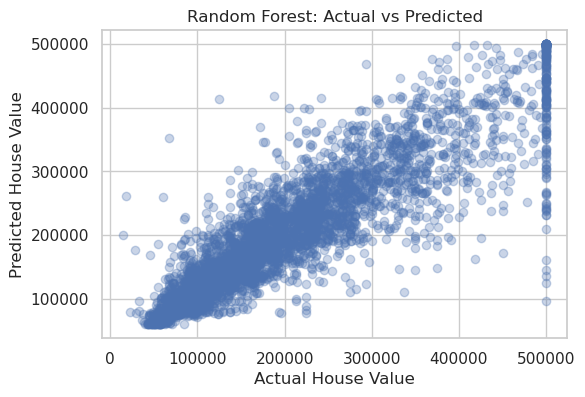

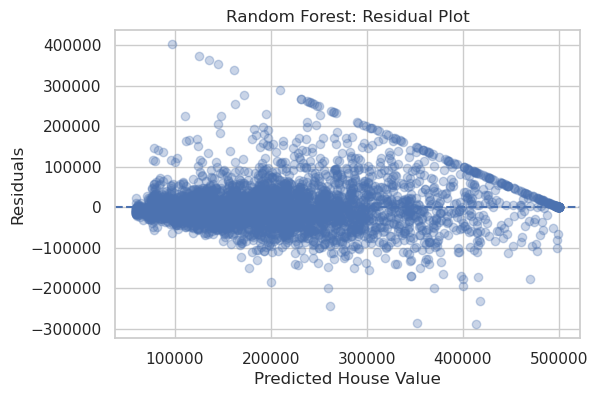

--- Gradient Boosting ---
MAE  : 36599.67
RMSE : 53662.45
R2   : 0.7802



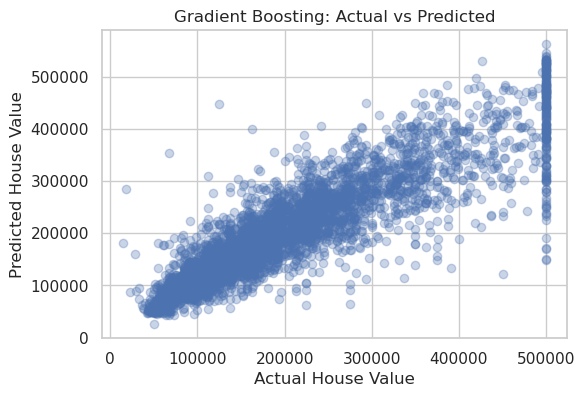

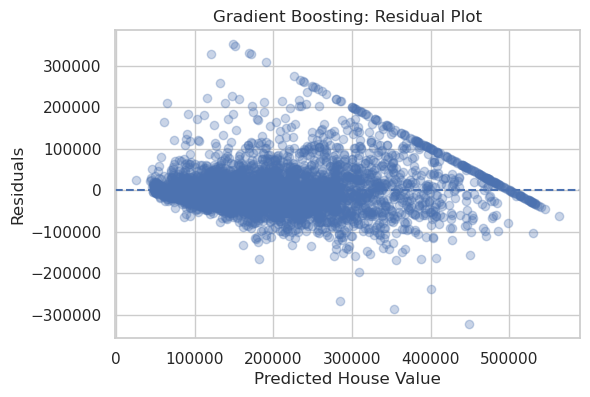

--- Linear Regression ---
MAE  : 50341.38
RMSE : 74493.28
R2   : 0.5765



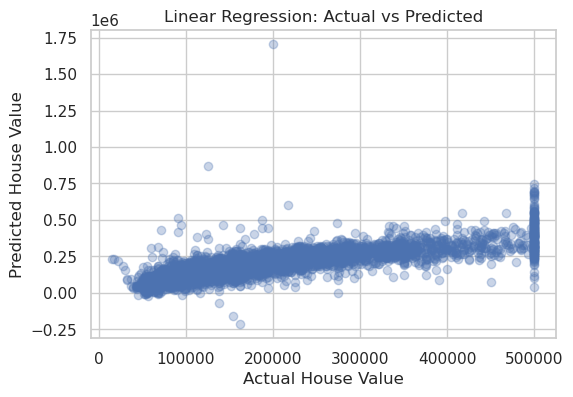

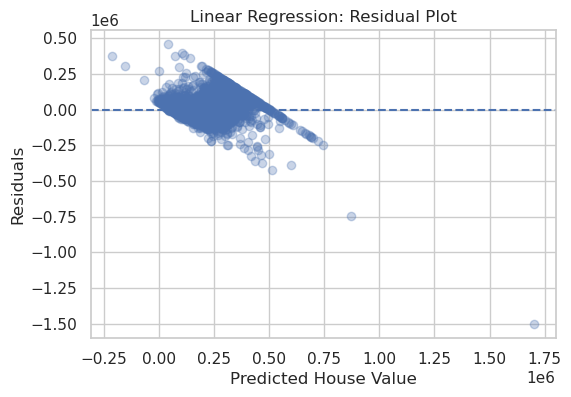

In [46]:
### Modeling 

# 1. Random Forest
rf_model, rf_preds, rf_results = train_evaluate_and_compare(
    RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=5, min_samples_leaf=2,
                          random_state=42, n_jobs=-1),
    x_train, y_train, x_test, y_test,
    "Random Forest")

# 2. Gradient Boosting
gb_model, gb_preds, gb_results = train_evaluate_and_compare(
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    x_train, y_train, x_test, y_test,
    "Gradient Boosting")

# 3. Linear Regression
lr_model, lr_preds, lr_results = train_evaluate_and_compare(
    LinearRegression(),
    x_train, y_train, x_test, y_test,
    "Linear Regression")

In [47]:
#Metrics Summary 

metrics_summary = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "Linear Regression"],
    "MAE": [
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, gb_preds),
        mean_absolute_error(y_test, lr_preds)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rf_preds)),
        np.sqrt(mean_squared_error(y_test, gb_preds)),
        np.sqrt(mean_squared_error(y_test, lr_preds))
    ],
    "R2": [
        r2_score(y_test, rf_preds),
        r2_score(y_test, gb_preds),
        r2_score(y_test, lr_preds)
    ]
})

metrics_summary

,Model,MAE,RMSE,R2
0,Random Forest,35603.195368,53462.198719,0.781884
1,Gradient Boosting,36599.670519,53662.446644,0.780247
2,Linear Regression,50341.375656,74493.275795,0.576525


In [50]:
# Combine actual values and all model predictions into one DataFrame
actual_vs_all = pd.DataFrame({
    "Actual": y_test.values,
    "RF_Predicted": rf_preds,
    "GB_Predicted": gb_preds,
    "LR_Predicted": lr_preds
})

# Check first few rows
actual_vs_all.head()

,Actual,RF_Predicted,GB_Predicted,LR_Predicted
0,47700.0,60024.328252,58626.517181,49699.650056
1,45800.0,168697.752653,88353.903605,125408.610142
2,500001.0,447442.679851,398616.830582,276812.884684
3,218600.0,251424.530826,257469.950839,260575.387786
4,278000.0,252054.268245,240674.988481,263108.684722


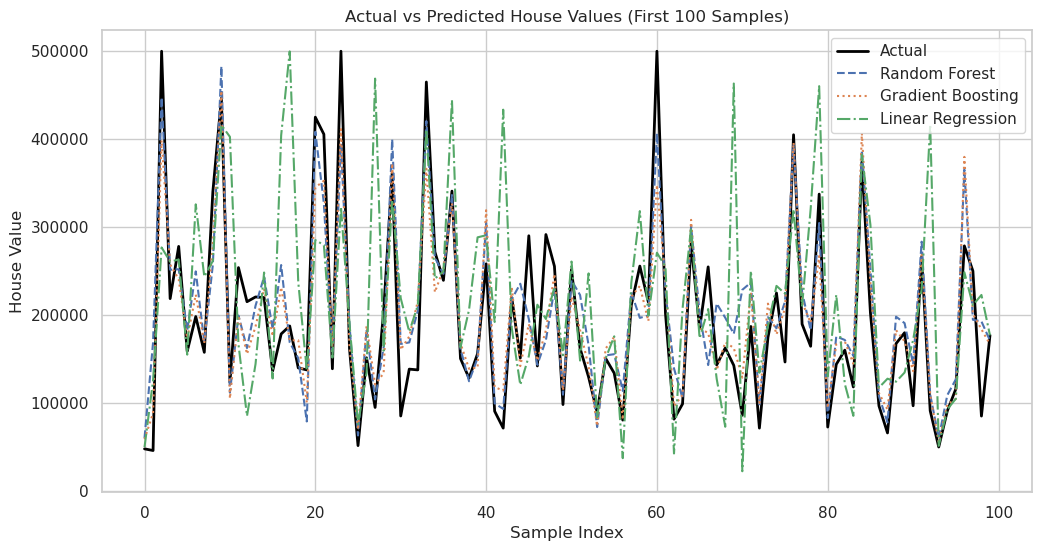

In [52]:
# Can change number of N 
N = 100  # you can adjust this
actual = actual_vs_all["Actual"][:N]
rf_pred = actual_vs_all["RF_Predicted"][:N]
gb_pred = actual_vs_all["GB_Predicted"][:N]
lr_pred = actual_vs_all["LR_Predicted"][:N]

plt.figure(figsize=(12,6))

# Plot actual values
plt.plot(actual.values, label="Actual", color="black", linewidth=2)

# Plot predictions
plt.plot(rf_pred.values, label="Random Forest", linestyle="--")
plt.plot(gb_pred.values, label="Gradient Boosting", linestyle=":")
plt.plot(lr_pred.values, label="Linear Regression", linestyle="-.")

plt.xlabel("Sample Index")
plt.ylabel("House Value")
plt.title("Actual vs Predicted House Values (First 100 Samples)")
plt.legend()
plt.show()

In [54]:
#Saving the Best Model locally to S3 Bucket
import joblib

# Save the Random Forest model locally[Best Model]

model_filename = "best_model_random_forest.joblib"
joblib.dump(rf_model, model_filename)
print(f"Random Forest model saved locally as: {model_filename}")


# Upload to your S3 bucket

bucket_name = "housewhiz-analytics-data"
s3 = boto3.client("s3")
model_key = f"models/{model_filename}"

s3.upload_file(model_filename, bucket_name, model_key)
print(f"Random Forest model uploaded to s3://{bucket_name}/{model_key}")

Random Forest model saved locally as: best_model_random_forest.joblib
Random Forest model uploaded to s3://housewhiz-analytics-data/models/best_model_random_forest.joblib
